In [ ]:
AWS                         Azure
----------------------------------------
S3                          Blob Storage
EC2                         Azure VM
Textract                    Document Intelligence (Form Recognizer)
Bedrock                     AI Foundry / Azure OpenAI


###Azure Account Structure :

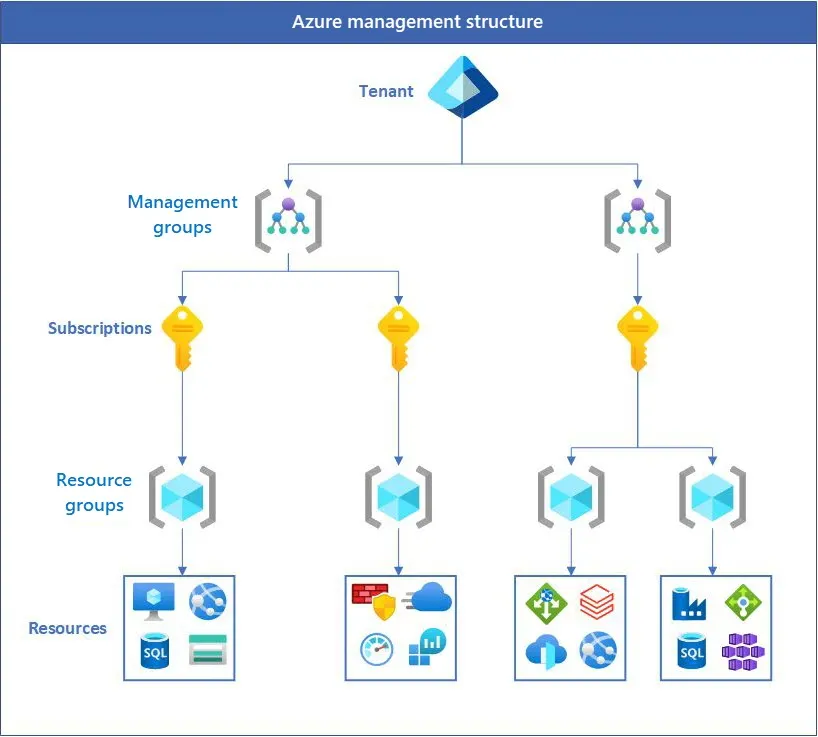

In [2]:
from IPython.display import Image
Image("/content/Azure-accounts-structure.jpg", width=300)

In [ ]:
Tenant : Root/main account of organization
Management Groups : Department or used to enforce policy
Subscriptions : To manage billing of different clients/projects
Resource Group : It is like a container, all resources for project created under same RG

In [ ]:
# https://azure.microsoft.com/en-us/pricing/free-services   --> create azure account

In [ ]:
## To use any resource you need to first create --> Resource Group

####Blob Storage :

In [ ]:
blob : binary large object

In [ ]:
>> Create Storage account

In [ ]:
AWS                  Azure
---------------------------
Object              blob
bucket              Container

In [ ]:
## Get connection string of storage account : (To coonect with this storage account)
In Storage account :
      -- Security + Networking (on left pannel)
      -- Access keys

In [ ]:
connection_string = "" 

In [4]:
!pip install azure-storage-blob

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.6/435.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 14.5 MB/s eta 0:00:00


In [5]:
## Client Setup (building connection) :
from azure.storage.blob import BlobServiceClient

blob_service_client = BlobServiceClient.from_connection_string(connection_string)

In [6]:
## Create container :
container_name = "mycontainer"

container = blob_service_client.create_container(container_name)

In [7]:
## upload file :
blob_client = blob_service_client.get_blob_client(
    container=container_name,  ## In which container to store uploaded file
    blob="myblob.jpg" ## Name of file to store
    )

with open("/content/Azure-accounts-structure.jpg", "rb") as data:
  blob_client.upload_blob(data)

In [8]:
## Download blob :
blob_client = blob_service_client.get_blob_client(
    container=container_name,  ## In which container to store uploaded file
    blob="myblob.jpg" ## Name of file to download
    )

with open("downloaded_blob.jpg", "wb") as download_file:
    download_file.write(blob_client.download_blob().readall())



####Azure VM :

In [ ]:
## Virtual Machine :

In [ ]:
>> Subscriptions & Resource
>> VM name :
>> Select Region
>> Select OS
>> Create & download private key

In [ ]:
## Connect with VM :
>> Open SSH Client (CMD...)
>> Locate your private key file
>> Run command :
ssh -i <name-of-key.pem> <username>@<ip-address>

In [ ]:
ssh -i my-vm-key.pem  azureuser@20.102.208.35

####Azure OpenAI :

In [ ]:
>> Create openai resource

In [10]:
!python -m pip install --upgrade pip packaging setuptools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.8 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cpu requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.


In [11]:
!pip install langchain-azure-ai

  Using cached langchain_azure_ai-1.2.5-py3-none-any.whl.metadata (23 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [langchain-azure-ai]


In [ ]:
endpoint = "https://velocity-260609.openai.azure.com/openai/v1"
key = ""

In [20]:
from langchain_azure_ai.chat_models import AzureAIOpenAIApiChatModel

model = AzureAIOpenAIApiChatModel(
    model="gpt-5.4-mini",
    endpoint=endpoint,
    credential=key
)

In [21]:
model.invoke("tell me about azure ai foundery?")

AIMessage(content='Azure AI Foundry is Microsoft’s platform for **building, evaluating, and deploying AI apps and agents** on Azure. It’s basically a unified experience for teams that want to work with foundation models, Azure AI services, and agent workflows in one place.\n\n### What you can do with it\n- **Discover models**: browse and compare models from Microsoft, OpenAI, Meta, Mistral, Cohere, etc. depending on availability.\n- **Build AI apps**: create chatbots, copilots, search/RAG apps, and custom AI experiences.\n- **Create agents**: define tools, instructions, memory, and orchestration for task-focused agents.\n- **Ground with your data**: connect enterprise data sources and use retrieval-augmented generation.\n- **Evaluate and test**: run evaluations for quality, groundedness, safety, latency, and cost.\n- **Deploy and monitor**: move solutions into production with Azure security, governance, and observability.\n\n### Common pieces you’ll see\n- **Model catalog**\n- **Prompt

####Document Intelligence :

In [ ]:
## To extract documents :

In [22]:
!pip install azure-ai-documentintelligence langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.4 MB/s  0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [langchain-community]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
from langchain_community.document_loaders import AzureAIDocumentIntelligenceLoader

loader = AzureAIDocumentIntelligenceLoader(
    api_endpoint="https://velocity.cognitiveservices.azure.com/",
    api_key = "",

    file_path = "/content/Agentic-RAG-Workflow.pdf"
)

In [26]:
docs = loader.load()